# BehaviorSpace Experiment 3: campaign-structure analysis

This notebook analyzes the third BehaviorSpace experiment:

- `reward-cycles`: 1, 2, 3, 4
- `reward-duration`: 20, 40, 60
- `withdrawal-duration`: 20, 40, 80
- `high-reward-salience`: 0.75, 0.90
- 30 stochastic repetitions per configuration

The full factorial design therefore contains:

\[
4 \times 3 \times 3 \times 2 \times 30 = 2160
\]

The notebook includes:

1. data-quality checks;
2. descriptive statistics;
3. a reusable `plot_faceted_heatmaps()` function;
4. faceted heatmaps for Persistence Index and Motivation Gap;
5. a static policy map;
6. interaction plots;
7. ranking of configurations;
8. statistical models;
9. updated conclusions for Experiment 3;
10. concise conclusions across Experiments 1–3.

> The findings describe the computational model under its assumptions. They should not be interpreted as empirical estimates for real shoppers.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import stats

CSV_PATH=Path("./experiments/e3-repeated-campaign-structure/table.csv")

# BehaviorSpace exports contain six metadata rows before the header.
df = pd.read_csv(CSV_PATH, skiprows=6)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 2,160
Columns: 32


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,[step],"choice-rate ""control"" ""baseline""","choice-rate ""low-salience"" ""baseline""",...,"mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-crowding-out-effect,low-reward-persistence-effect,high-reward-withdrawal-drop,low-reward-withdrawal-drop,high-reward-retention-ratio,low-reward-retention-ratio
0,7,1000,1,20,20,0.15,0.75,70,0.375449,0.375676,...,0.481063,0.415569,0.466366,0.485285,0.069716,0.050798,0.294895,0.048949,0.622017,0.905012
1,3,1000,1,20,20,0.15,0.75,70,0.390220,0.373674,...,0.464601,0.411527,0.454354,0.491742,0.080215,0.042827,0.283183,0.040991,0.634567,0.917248
2,1,1000,1,20,20,0.15,0.75,70,0.369261,0.370871,...,0.479086,0.417515,0.462613,0.479279,0.061764,0.045098,0.303303,0.037538,0.612433,0.924947
3,6,1000,1,20,20,0.15,0.75,70,0.369760,0.385385,...,0.462988,0.391168,0.479129,0.469970,0.078802,0.087961,0.293844,0.033784,0.615294,0.934133
4,4,1000,1,20,20,0.15,0.75,70,0.372555,0.393894,...,0.459119,0.411677,0.464414,0.481832,0.070155,0.052738,0.279129,0.053003,0.633189,0.897562


## 1. Data quality and experimental design

In [2]:
design_columns = [
    "reward-cycles",
    "reward-duration",
    "withdrawal-duration",
    "high-reward-salience",
]

print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

display(df[design_columns].nunique().to_frame("number of levels"))
display(
    df.groupby(design_columns)
      .size()
      .describe()
      .to_frame("repetitions per configuration")
)

expected_rows = (
    df["reward-cycles"].nunique()
    * df["reward-duration"].nunique()
    * df["withdrawal-duration"].nunique()
    * df["high-reward-salience"].nunique()
    * 30
)
print("Expected rows:", expected_rows)
print("Observed rows:", len(df))


Missing values: 0
Duplicate rows: 0


,number of levels
reward-cycles,4
reward-duration,3
withdrawal-duration,3
high-reward-salience,2


,repetitions per configuration
count,72.0
mean,30.0
std,0.0
min,30.0
25%,30.0
50%,30.0
75%,30.0
max,30.0


Expected rows: 2160
Observed rows: 2160


## 2. Rename and select the main metrics

In [3]:
metric_map = {
    'choice-rate "high-salience" "reward"': "reward_choice_rate",
    'persistence "high-salience"': "persistence",
    'persistence-index "high-salience"': "persistence_index",
    'mean-intrinsic-motivation "high-salience"': "intrinsic_motivation",
    'mean-habit "high-salience"': "habit_strength",
    "high-reward-crowding-out-effect": "motivation_gap_vs_control",
    "high-reward-withdrawal-drop": "withdrawal_drop",
    "high-reward-retention-ratio": "retention_ratio",
}

analysis_df = df.rename(columns=metric_map).copy()
metrics = list(metric_map.values())

analysis_df[
    design_columns + metrics
].head()


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,intrinsic_motivation,habit_strength,motivation_gap_vs_control,withdrawal_drop,retention_ratio
0,1,20,20,0.75,0.780180,0.485285,0.114014,0.481063,0.485285,0.069716,0.294895,0.622017
1,1,20,20,0.75,0.774925,0.491742,0.108158,0.464601,0.491742,0.080215,0.283183,0.634567
2,1,20,20,0.75,0.782583,0.479279,0.100200,0.479086,0.479279,0.061764,0.303303,0.612433
3,1,20,20,0.75,0.763814,0.469970,0.095295,0.462988,0.469970,0.078802,0.293844,0.615294
4,1,20,20,0.75,0.760961,0.481832,0.120170,0.459119,0.481832,0.070155,0.279129,0.633189


## 3. Configuration-level summary

In [4]:
summary = (
    analysis_df
    .groupby(design_columns)[metrics]
    .agg(["mean", "std", "count"])
)

summary.columns = [
    f"{metric}_{statistic}"
    for metric, statistic in summary.columns
]
summary = summary.reset_index()

# Flat table of means, convenient for plotting.
mean_columns = {
    f"{metric}_mean": metric
    for metric in metrics
}
mean_summary = summary[
    design_columns + list(mean_columns)
].rename(columns=mean_columns)

display(mean_summary.head())
print("Configurations:", len(mean_summary))


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,intrinsic_motivation,habit_strength,motivation_gap_vs_control,withdrawal_drop,retention_ratio
0,1,20,20,0.75,0.776301,0.491867,0.113308,0.470868,0.491867,0.079876,0.284434,0.633593
1,1,20,20,0.90,0.820090,0.493794,0.117918,0.440739,0.493794,0.075670,0.326296,0.602124
2,1,20,40,0.75,0.775150,0.459887,0.082967,0.471607,0.425781,0.042822,0.315263,0.593315
3,1,20,40,0.90,0.823949,0.454552,0.077025,0.440947,0.415696,0.036483,0.369397,0.551654
4,1,20,80,0.75,0.775591,0.433846,0.057316,0.468791,0.406386,0.016179,0.341744,0.559386


Configurations: 72


## 4. Marginal effects

In [5]:
marginal_metrics = [
    "reward_choice_rate",
    "persistence",
    "persistence_index",
    "motivation_gap_vs_control",
    "intrinsic_motivation",
    "habit_strength",
    "withdrawal_drop",
    "retention_ratio",
]

for parameter in design_columns:
    print(f"\n### {parameter}")
    display(
        analysis_df.groupby(parameter)[marginal_metrics]
        .mean()
        .round(4)
    )



### reward-cycles


,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
reward-cycles,,,,,,,,
1,0.8172,0.4521,0.0748,0.0363,0.4174,0.4282,0.3651,0.5541
2,0.8122,0.4322,0.0551,0.0162,0.3561,0.4084,0.3800,0.5329
3,0.8071,0.4169,0.0397,0.0002,0.3076,0.3930,0.3902,0.5174
4,0.8021,0.4044,0.0277,-0.0117,0.2695,0.3806,0.3976,0.5050



### reward-duration


,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
reward-duration,,,,,,,,
20,0.7957,0.4438,0.0665,0.0276,0.4036,0.4219,0.3519,0.5582
40,0.8142,0.4255,0.0487,0.0093,0.3313,0.4006,0.3887,0.5230
60,0.8190,0.4099,0.0328,-0.0061,0.2780,0.3851,0.4091,0.5009



### withdrawal-duration


,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
withdrawal-duration,,,,,,,,
20,0.812,0.4640,0.0869,0.0478,0.3375,0.4640,0.3479,0.5722
40,0.809,0.4222,0.0449,0.0060,0.3375,0.3810,0.3868,0.5226
80,0.808,0.3930,0.0162,-0.0231,0.3380,0.3627,0.4150,0.4872



### high-reward-salience


,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
high-reward-salience,,,,,,,,
0.75,0.7891,0.4360,0.0595,0.0203,0.3801,0.4135,0.3531,0.5526
0.90,0.8301,0.4168,0.0392,0.0002,0.2952,0.3916,0.4133,0.5021


### Important interpretation of withdrawal duration

In this implementation, a longer final withdrawal period does **not** improve persistence. The target-choice history and habit can decay during a longer reward-free phase. Consequently, longer withdrawal duration produces a stricter test of durability and lowers the measured end-state Persistence Index.

This differs from an interpretation in which withdrawal time is assumed to restore motivation automatically. The actual model results must take precedence over that expectation.


## 5. Reusable faceted heatmap function

In [6]:
def plot_faceted_heatmaps(
    data,
    metric,
    row_facet="high-reward-salience",
    col_facet="reward-cycles",
    y="reward-duration",
    x="withdrawal-duration",
    aggregation="mean",
    title=None,
    value_format=".3f",
    center_zero=False,
):
    """Plot a grid of heatmaps using only pandas and matplotlib.

    Parameters
    ----------
    data : pandas.DataFrame
        Row-level simulation data or an already aggregated table.
    metric : str
        Numeric metric displayed in the cells.
    row_facet, col_facet : str
        Variables defining heatmap rows and columns.
    y, x : str
        Variables displayed on vertical and horizontal axes.
    aggregation : str or callable
        Aggregation used by pivot_table.
    title : str, optional
        Figure title.
    value_format : str
        Format used for cell annotations.
    center_zero : bool
        When True, use a symmetric range around zero.
    """
    row_values = sorted(data[row_facet].dropna().unique())
    col_values = sorted(data[col_facet].dropna().unique())

    # A common scale is essential for comparison across facets.
    pivots = {}
    all_values = []

    for row_value in row_values:
        for col_value in col_values:
            subset = data[
                (data[row_facet] == row_value)
                & (data[col_facet] == col_value)
            ]
            pivot = subset.pivot_table(
                values=metric,
                index=y,
                columns=x,
                aggfunc=aggregation,
            ).sort_index().sort_index(axis=1)

            pivots[(row_value, col_value)] = pivot
            all_values.extend(pivot.to_numpy().ravel())

    finite_values = np.asarray(all_values, dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]

    if center_zero:
        limit = np.max(np.abs(finite_values))
        vmin, vmax = -limit, limit
        cmap = "coolwarm"
    else:
        vmin, vmax = finite_values.min(), finite_values.max()
        cmap = "viridis"

    fig, axes = plt.subplots(
        len(row_values),
        len(col_values),
        figsize=(4.3 * len(col_values), 3.7 * len(row_values)),
        squeeze=False,
        constrained_layout=True,
    )

    image = None

    for row_index, row_value in enumerate(row_values):
        for col_index, col_value in enumerate(col_values):
            ax = axes[row_index, col_index]
            pivot = pivots[(row_value, col_value)]

            image = ax.imshow(
                pivot.to_numpy(),
                aspect="auto",
                origin="lower",
                vmin=vmin,
                vmax=vmax,
                cmap=cmap,
            )

            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns)
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels(pivot.index)

            ax.set_xlabel(x.replace("-", " ").title())
            ax.set_ylabel(y.replace("-", " ").title())
            ax.set_title(
                f"{row_facet}={row_value}, {col_facet}={col_value}"
            )

            threshold = (vmin + vmax) / 2

            for i in range(len(pivot.index)):
                for j in range(len(pivot.columns)):
                    value = pivot.iloc[i, j]
                    if np.isfinite(value):
                        text_color = (
                            "white"
                            if (value < threshold and not center_zero)
                            or (center_zero and abs(value) > 0.55 * vmax)
                            else "black"
                        )
                        ax.text(
                            j,
                            i,
                            format(value, value_format),
                            ha="center",
                            va="center",
                            color=text_color,
                            fontsize=9,
                        )

    if title:
        fig.suptitle(title, fontsize=15)

    label = metric.replace("_", " ").title()
    fig.colorbar(image, ax=axes, shrink=0.85, label=label)
    plt.show()


## 6. Faceted heatmap: Persistence Index

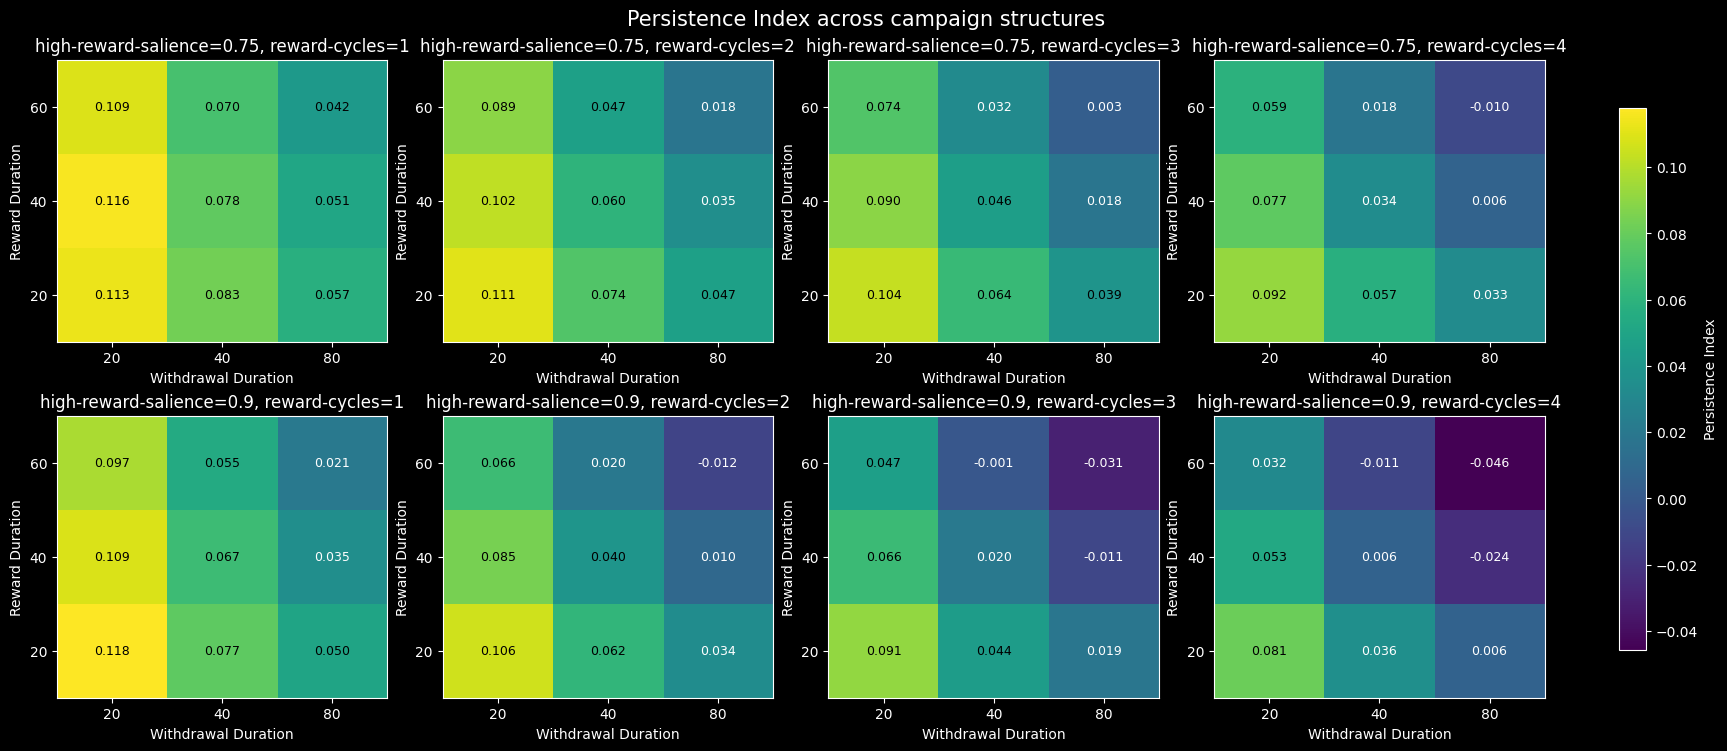

In [7]:
plot_faceted_heatmaps(
    analysis_df,
    metric="persistence_index",
    title="Persistence Index across campaign structures",
)


How to read the figure:

- each row corresponds to reward salience (`0.75` or `0.90`);
- each column corresponds to the number of campaigns;
- within each heatmap:
  - X = withdrawal duration;
  - Y = reward duration;
  - cell value = mean Persistence Index.

Higher values indicate a larger target-choice rate after reward withdrawal relative to baseline.


## 7. Faceted heatmap: Motivation Gap vs Control

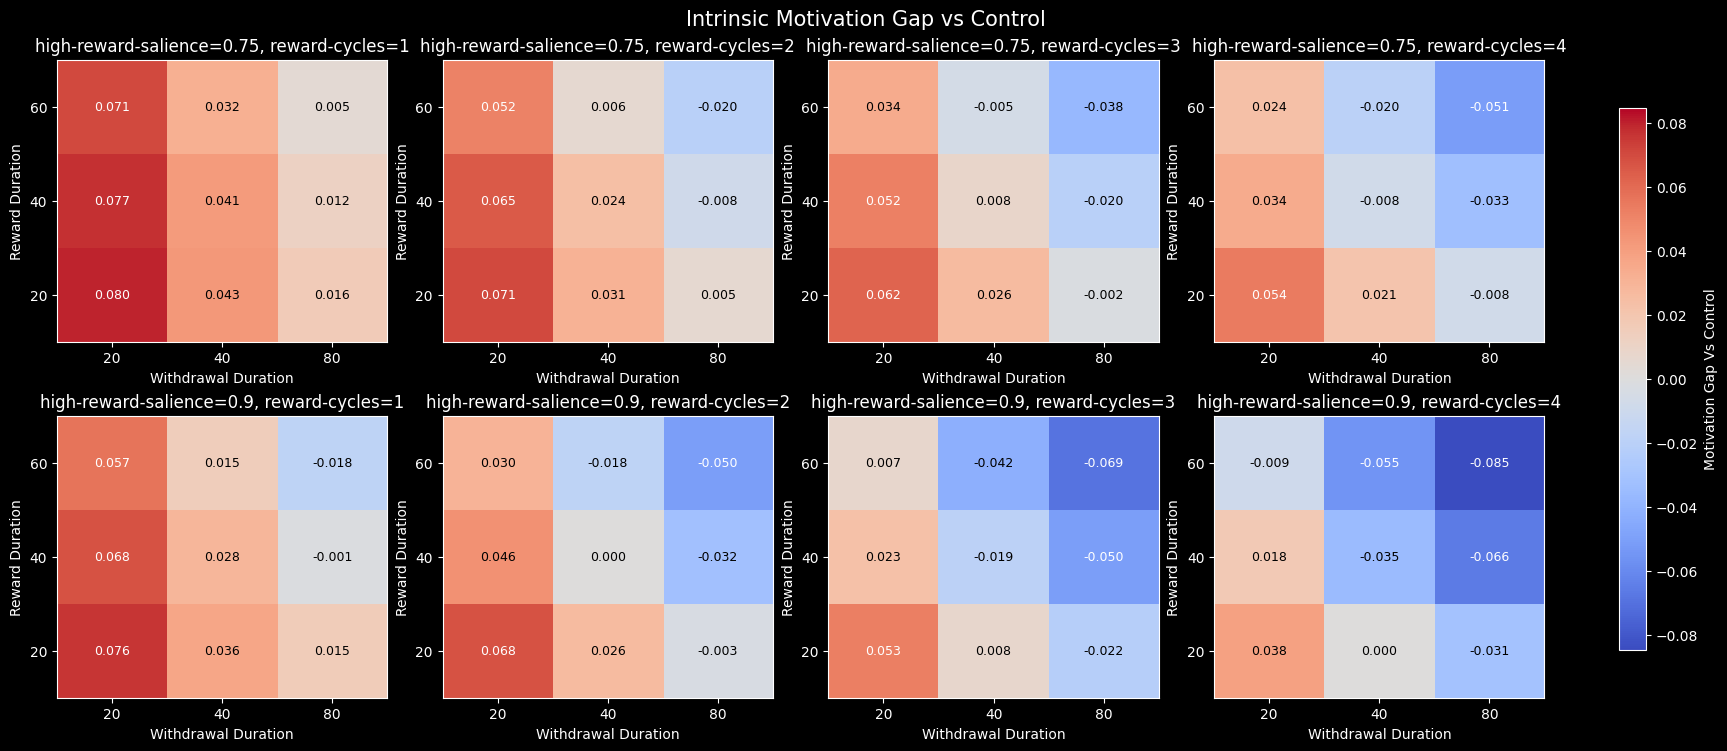

In [8]:
plot_faceted_heatmaps(
    analysis_df,
    metric="motivation_gap_vs_control",
    title="Intrinsic Motivation Gap vs Control",
    center_zero=True,
)


Interpretation:

- positive values: intrinsic motivation in the rewarded group remains above control;
- zero: no difference from control;
- negative values: motivational crowding-out relative to control.

The common color scale makes the expansion of the negative region across campaign configurations visible.


## 8. Static policy map

The policy map translates two outcomes into decision-oriented categories.

Classification rules used here:

- **Preferred**: non-negative Motivation Gap and Persistence Index in the top quartile;
- **Acceptable**: non-negative Motivation Gap and positive Persistence Index;
- **Crowding-out risk**: negative Motivation Gap but positive Persistence Index;
- **Avoid**: non-positive Persistence Index.

The thresholds are analytical choices, not theoretical constants. They can be modified.


In [9]:
def classify_policy_regions(data):
    result = data.copy()
    high_persistence_threshold = result["persistence_index"].quantile(0.75)

    conditions = [
        (
            (result["motivation_gap_vs_control"] >= 0)
            & (result["persistence_index"] >= high_persistence_threshold)
        ),
        (
            (result["motivation_gap_vs_control"] >= 0)
            & (result["persistence_index"] > 0)
        ),
        (
            (result["motivation_gap_vs_control"] < 0)
            & (result["persistence_index"] > 0)
        ),
        result["persistence_index"] <= 0,
    ]

    labels = [
        "Preferred",
        "Acceptable",
        "Crowding-out risk",
        "Avoid",
    ]

    result["policy_region"] = np.select(
        conditions,
        labels,
        default="Unclassified",
    )
    return result, high_persistence_threshold


policy_df, pi_threshold = classify_policy_regions(mean_summary)

print("Top-quartile Persistence Index threshold:", round(pi_threshold, 4))
display(
    policy_df["policy_region"]
    .value_counts()
    .rename("configurations")
    .to_frame()
)


Top-quartile Persistence Index threshold: 0.0772


,configurations
policy_region,
Acceptable,26
Crowding-out risk,20
Preferred,18
Avoid,8


/var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/ipykernel_97618/2998889097.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  codes = pivot.replace(category_to_code).astype(float)
/var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/ipykernel_97618/2998889097.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  codes = pivot.replace(category_to_code).astype(float)


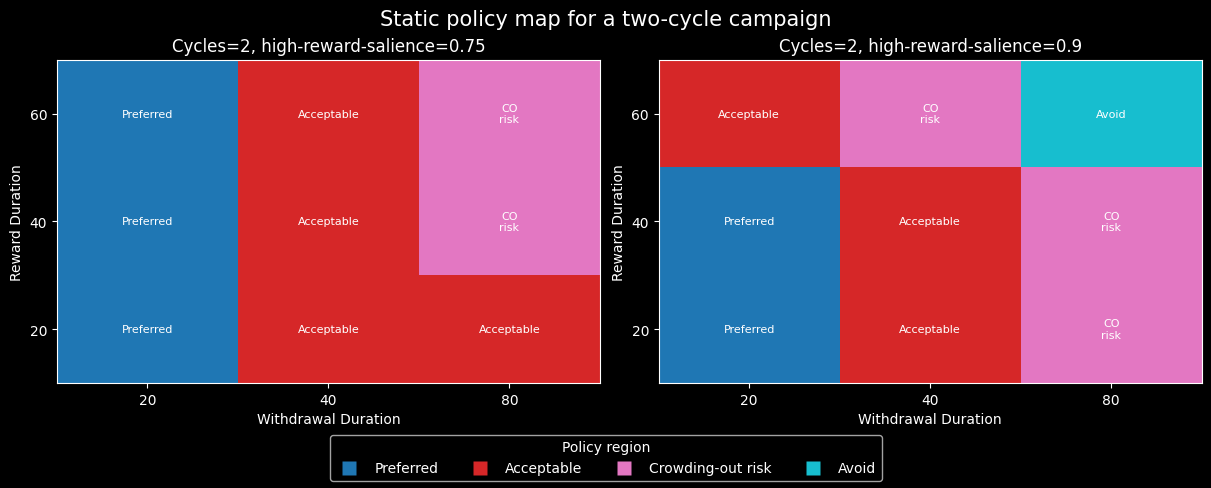

In [10]:
def plot_policy_map(
    policy_data,
    selected_cycles=2,
    y="reward-duration",
    x="withdrawal-duration",
    facet="high-reward-salience",
):
    categories = [
        "Preferred",
        "Acceptable",
        "Crowding-out risk",
        "Avoid",
    ]
    category_to_code = {
        category: index
        for index, category in enumerate(categories)
    }

    subset = policy_data[
        policy_data["reward-cycles"] == selected_cycles
    ].copy()

    facet_values = sorted(subset[facet].unique())

    fig, axes = plt.subplots(
        1,
        len(facet_values),
        figsize=(6 * len(facet_values), 4.8),
        squeeze=False,
        constrained_layout=True,
    )

    cmap = ListedColormap(plt.cm.tab10(np.linspace(0, 1, len(categories))))

    for index, facet_value in enumerate(facet_values):
        ax = axes[0, index]
        facet_df = subset[subset[facet] == facet_value]

        pivot = facet_df.pivot(
            index=y,
            columns=x,
            values="policy_region",
        ).sort_index().sort_index(axis=1)

        codes = pivot.replace(category_to_code).astype(float)

        ax.imshow(
            codes.to_numpy(),
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=-0.5,
            vmax=len(categories) - 0.5,
        )

        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel(x.replace("-", " ").title())
        ax.set_ylabel(y.replace("-", " ").title())
        ax.set_title(
            f"Cycles={selected_cycles}, {facet}={facet_value}"
        )

        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                label = pivot.iloc[i, j]
                ax.text(
                    j,
                    i,
                    label.replace("Crowding-out ", "CO\n"),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="s",
            linestyle="",
            markersize=10,
            markerfacecolor=cmap(index),
            markeredgecolor="none",
            label=category,
        )
        for index, category in enumerate(categories)
    ]

    fig.legend(
        handles=handles,
        loc="outside lower center",
        ncol=len(categories),
        title="Policy region",
    )
    fig.suptitle(
        "Static policy map for a two-cycle campaign",
        fontsize=15,
    )
    plt.show()


plot_policy_map(policy_df, selected_cycles=2)


The two-cycle slice is used because it is a practical intermediate design rather than an assumed optimum. Change `selected_cycles` to 1, 3, or 4 to inspect another policy map.


## 9. Interaction plots

In [11]:
def plot_interaction(
    data,
    outcome,
    x,
    line,
    facet,
    fixed_parameter=None,
    fixed_value=None,
    title=None,
):
    plot_data = data.copy()

    if fixed_parameter is not None:
        plot_data = plot_data[
            plot_data[fixed_parameter] == fixed_value
        ]

    facet_values = sorted(plot_data[facet].unique())
    line_values = sorted(plot_data[line].unique())

    fig, axes = plt.subplots(
        1,
        len(facet_values),
        figsize=(6.5 * len(facet_values), 4.8),
        squeeze=False,
        constrained_layout=True,
    )

    for facet_index, facet_value in enumerate(facet_values):
        ax = axes[0, facet_index]
        facet_data = plot_data[plot_data[facet] == facet_value]

        for line_value in line_values:
            subset = facet_data[facet_data[line] == line_value]
            curve = subset.groupby(x)[outcome].mean().sort_index()

            ax.plot(
                curve.index,
                curve.values,
                marker="o",
                label=f"{line}={line_value}",
            )

        ax.axhline(0, linewidth=1)
        ax.set_xlabel(x.replace("-", " ").title())
        ax.set_ylabel(outcome.replace("_", " ").title())
        ax.set_title(f"{facet}={facet_value}")
        ax.grid(alpha=0.25)
        ax.legend()

    if title:
        fig.suptitle(title, fontsize=15)

    plt.show()


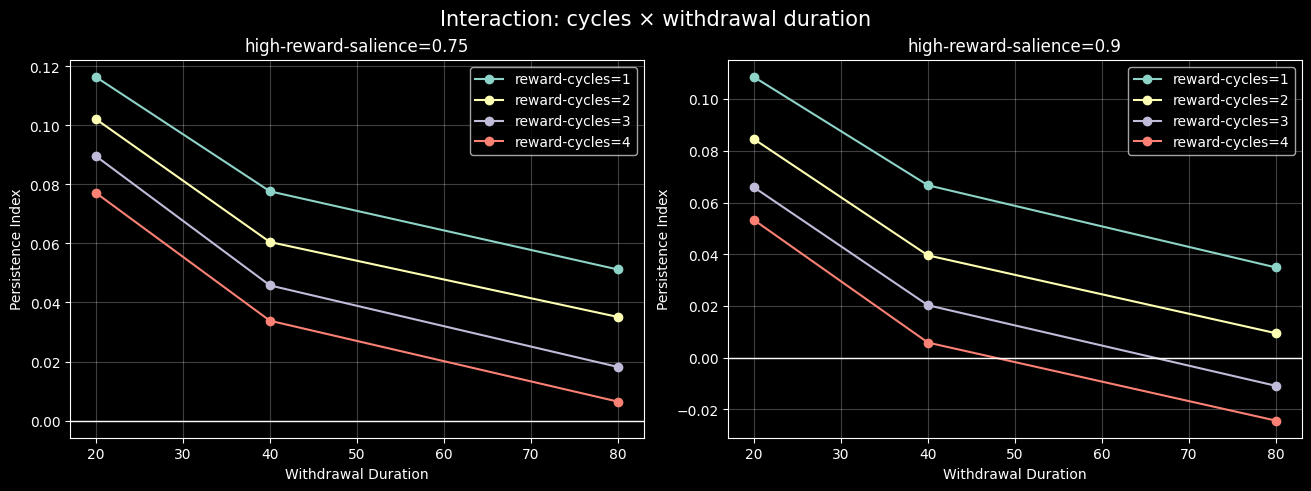

In [12]:
# Persistence Index versus withdrawal duration,
# with one line per number of cycles.
# Reward duration is fixed at the middle tested value (40).

plot_interaction(
    analysis_df,
    outcome="persistence_index",
    x="withdrawal-duration",
    line="reward-cycles",
    facet="high-reward-salience",
    fixed_parameter="reward-duration",
    fixed_value=40,
    title="Interaction: cycles × withdrawal duration",
)


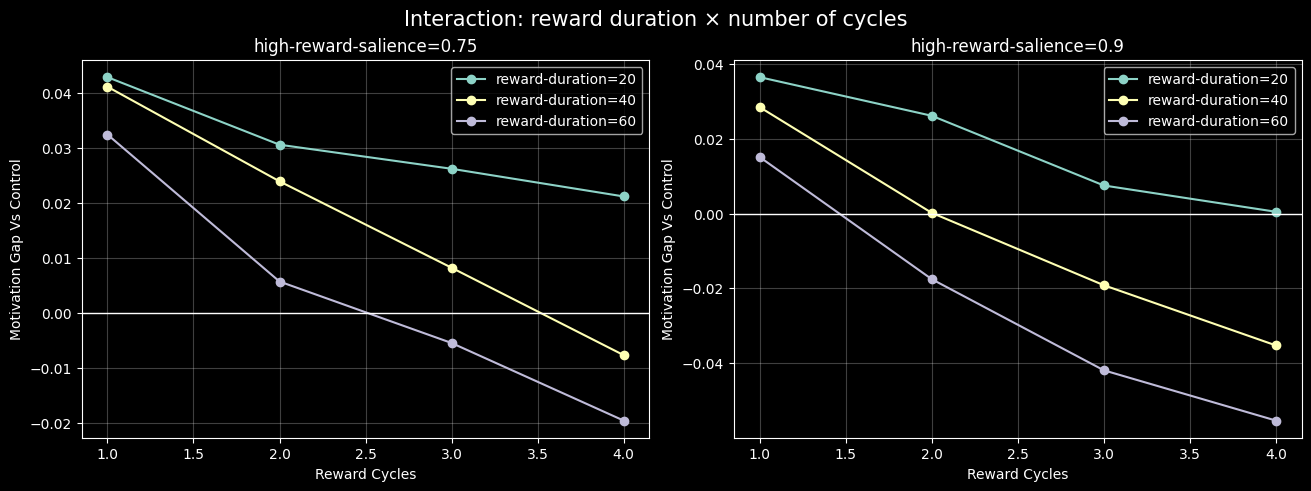

In [13]:
# Motivation Gap versus number of cycles,
# with one line per reward duration.
# Withdrawal duration is fixed at 40.

plot_interaction(
    analysis_df,
    outcome="motivation_gap_vs_control",
    x="reward-cycles",
    line="reward-duration",
    facet="high-reward-salience",
    fixed_parameter="withdrawal-duration",
    fixed_value=40,
    title="Interaction: reward duration × number of cycles",
)


## 10. Rank configurations

In [14]:
ranking_columns = design_columns + [
    "reward_choice_rate",
    "persistence",
    "persistence_index",
    "motivation_gap_vs_control",
    "intrinsic_motivation",
    "habit_strength",
    "withdrawal_drop",
    "retention_ratio",
]

print("Top 15 configurations by Persistence Index")
display(
    mean_summary[ranking_columns]
    .sort_values("persistence_index", ascending=False)
    .head(15)
    .round(4)
)

print("Bottom 15 configurations by Persistence Index")
display(
    mean_summary[ranking_columns]
    .sort_values("persistence_index")
    .head(15)
    .round(4)
)


Top 15 configurations by Persistence Index


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
1,1,20,20,0.90,0.8201,0.4938,0.1179,0.0757,0.4407,0.4938,0.3263,0.6021
6,1,40,20,0.75,0.8019,0.4950,0.1163,0.0768,0.4440,0.4950,0.3068,0.6173
0,1,20,20,0.75,0.7763,0.4919,0.1133,0.0799,0.4709,0.4919,0.2844,0.6336
18,2,20,20,0.75,0.7795,0.4880,0.1105,0.0707,0.4451,0.4880,0.2915,0.6261
12,1,60,20,0.75,0.8093,0.4855,0.1091,0.0707,0.4166,0.4855,0.3238,0.5999
7,1,40,20,0.90,0.8426,0.4850,0.1086,0.0675,0.3890,0.4850,0.3576,0.5756
19,2,20,20,0.90,0.8241,0.4836,0.1058,0.0675,0.3927,0.4836,0.3405,0.5868
36,3,20,20,0.75,0.7766,0.4778,0.1038,0.0617,0.4199,0.4778,0.2989,0.6152
24,2,40,20,0.75,0.7983,0.4785,0.1021,0.0652,0.3971,0.4785,0.3199,0.5993
13,1,60,20,0.90,0.8502,0.4733,0.0968,0.0569,0.3465,0.4733,0.3769,0.5567


Bottom 15 configurations by Persistence Index


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,reward_choice_rate,persistence,persistence_index,motivation_gap_vs_control,intrinsic_motivation,habit_strength,withdrawal_drop,retention_ratio
71,4,60,80,0.90,0.8250,0.3331,-0.0457,-0.0847,0.1369,0.3008,0.4919,0.4037
53,3,60,80,0.90,0.8323,0.3477,-0.0308,-0.0689,0.1794,0.3154,0.4846,0.4177
65,4,40,80,0.90,0.8227,0.3513,-0.0243,-0.0661,0.1996,0.3189,0.4714,0.4270
35,2,60,80,0.90,0.8418,0.3674,-0.0124,-0.0504,0.2450,0.3360,0.4744,0.4364
69,4,60,40,0.90,0.8241,0.3627,-0.0115,-0.0554,0.1333,0.3176,0.4614,0.4401
47,3,40,80,0.90,0.8292,0.3663,-0.0108,-0.0503,0.2457,0.3325,0.4629,0.4417
70,4,60,80,0.75,0.7889,0.3640,-0.0096,-0.0511,0.2558,0.3338,0.4249,0.4614
51,3,60,40,0.90,0.8330,0.3761,-0.0014,-0.0419,0.1784,0.3310,0.4568,0.4515
52,3,60,80,0.75,0.7943,0.3778,0.0032,-0.0376,0.3008,0.3487,0.4164,0.4756
59,4,20,80,0.90,0.8099,0.3850,0.0056,-0.0310,0.3129,0.3569,0.4250,0.4753


## 11. Pareto-efficient configurations

In [15]:
def pareto_front(
    data,
    maximize,
    minimize=None,
):
    minimize = minimize or []
    values = data[maximize + minimize].copy()

    # Convert all objectives to maximization.
    for column in minimize:
        values[column] = -values[column]

    array = values.to_numpy(dtype=float)
    efficient = np.ones(len(array), dtype=bool)

    for i, candidate in enumerate(array):
        if not efficient[i]:
            continue

        dominated_by_other = np.any(
            np.all(array >= candidate, axis=1)
            & np.any(array > candidate, axis=1)
        )
        if dominated_by_other:
            efficient[i] = False

    return data.loc[efficient].copy()


pareto = pareto_front(
    mean_summary,
    maximize=[
        "persistence_index",
        "reward_choice_rate",
        "motivation_gap_vs_control",
    ],
)

display(
    pareto[
        design_columns
        + [
            "reward_choice_rate",
            "persistence_index",
            "motivation_gap_vs_control",
        ]
    ]
    .sort_values(
        ["persistence_index", "reward_choice_rate"],
        ascending=False,
    )
    .round(4)
)


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,reward_choice_rate,persistence_index,motivation_gap_vs_control
1,1,20,20,0.90,0.8201,0.1179,0.0757
6,1,40,20,0.75,0.8019,0.1163,0.0768
0,1,20,20,0.75,0.7763,0.1133,0.0799
7,1,40,20,0.90,0.8426,0.1086,0.0675
13,1,60,20,0.90,0.8502,0.0968,0.0569
15,1,60,40,0.90,0.8504,0.0545,0.0151
17,1,60,80,0.90,0.8514,0.0207,-0.0176


## 12. Statistical analysis

In [16]:
# Spearman associations provide a compact description of monotonic effects.
association_rows = []

for parameter in design_columns:
    for metric in [
        "reward_choice_rate",
        "persistence_index",
        "motivation_gap_vs_control",
        "retention_ratio",
    ]:
        rho, p_value = stats.spearmanr(
            analysis_df[parameter],
            analysis_df[metric],
        )
        association_rows.append(
            {
                "parameter": parameter,
                "metric": metric,
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )

associations = pd.DataFrame(association_rows)
display(associations.round(5))


,parameter,metric,spearman_rho,p_value
0,reward-cycles,reward_choice_rate,-0.22930,0.00000
1,reward-cycles,persistence_index,-0.43331,0.00000
2,reward-cycles,motivation_gap_vs_control,-0.42290,0.00000
3,reward-cycles,retention_ratio,-0.32592,0.00000
4,reward-duration,reward_choice_rate,0.37080,0.00000
5,reward-duration,persistence_index,-0.33468,0.00000
6,reward-duration,motivation_gap_vs_control,-0.32305,0.00000
7,reward-duration,retention_ratio,-0.42858,0.00000
8,withdrawal-duration,reward_choice_rate,-0.06389,0.00297
9,withdrawal-duration,persistence_index,-0.74342,0.00000


Because these are stochastic simulation repetitions rather than sampled human participants, p-values mainly quantify whether differences are large relative to model noise. Response surfaces, effect sizes, and the direction of the modeled trade-offs are more important than statistical significance alone.


## 13. Updated conclusions for Experiment 3

### 13.1 Campaign structure materially changes post-reward durability

The 72 tested configurations produce visibly different Persistence Index values. Therefore, long-term behavior is not determined by reward salience alone; it depends on how rewards and withdrawals are arranged over time.

### 13.2 More reward cycles reduce persistence in the tested design

The marginal mean Persistence Index decreases from approximately:

- **0.075** with one cycle;
- **0.055** with two cycles;
- **0.040** with three cycles;
- **0.028** with four cycles.

The repeated campaigns do not generate a monotonic durability benefit. Under the current rules, the additional exposure and repeated post-reward decay outweigh any extra habit-building benefit.

### 13.3 Longer reward duration also reduces the final Persistence Index

The marginal mean Persistence Index decreases from approximately:

- **0.067** at 20 reward ticks;
- **0.049** at 40 ticks;
- **0.033** at 60 ticks.

A longer campaign may raise or sustain target choice while rewards are active, but it does not improve the end-state durability measure. The additional rewarded exposure is associated with lower intrinsic motivation and weaker post-withdrawal retention.

### 13.4 Longer withdrawal duration is a stricter durability test, not a recovery mechanism

The strongest marginal effect is observed for withdrawal duration:

- **0.087** at 20 ticks;
- **0.045** at 40 ticks;
- **0.016** at 80 ticks.

The Motivation Gap also moves from positive to negative on average as withdrawal duration increases. This means that a behavior may appear persistent shortly after rewards stop but continue to decay over a longer reward-free period.

Therefore, “persistence” must always be reported together with the length of the post-program observation window.

### 13.5 Higher reward salience improves campaign uptake but weakens durability

Compared with salience `0.75`, salience `0.90` produces higher target choice during the reward phase but lower:

- Persistence Index;
- intrinsic motivation;
- habit strength at the final measurement;
- retention ratio.

This reproduces the central short-term-versus-long-term trade-off found in Experiments 1 and 2.

### 13.6 The best configurations are concentrated in short, lightly repeated structures

The highest Persistence Index values occur mainly with:

- one or two cycles;
- short reward durations;
- short withdrawal measurement windows.

However, this does **not** mean that a short withdrawal period is normatively better. It means that behavior is measured sooner after reward removal. For a fair policy comparison, the final follow-up horizon should be fixed across candidate programs.

### 13.7 The policy map reveals three practical regions

The tested configurations can be separated into:

1. **Preferred region** — relatively high persistence and no negative Motivation Gap;
2. **Acceptable region** — positive persistence and no modeled crowding-out;
3. **Crowding-out-risk region** — behavior remains above baseline, but intrinsic motivation is below control.

This distinction is important because a positive Persistence Index alone can conceal motivational damage.

### 13.8 Main conclusion of Experiment 3

The model does not support the rule “more campaigns are better.” Repeating or extending a salient reward can improve immediate uptake while gradually reducing the durability and motivational quality of the behavior.

The experimental result therefore supports optimizing the **whole campaign configuration**, not maximizing any single reward parameter.


## 14. Concise conclusions across all three experiments

### Experiment 1 — Reward magnitude

Increasing reward salience consistently increases target choice during the campaign. However, Persistence Index, intrinsic motivation, and retention decline. The Motivation Gap crosses below control between the tested salience values `0.75` and `0.85`.

**Conclusion:** the reward level that maximizes short-term uptake is not the level that maximizes post-reward durability.

### Experiment 2 — Reward magnitude × duration

Reward magnitude and duration interact. Stronger and longer rewards provide high campaign uptake but progressively increase motivational crowding-out and weaken persistence after withdrawal.

**Conclusion:** there is a response surface rather than one universally optimal reward. Useful configurations balance habit formation against motivational loss.

### Experiment 3 — Campaign structure

Increasing the number of cycles, reward duration, and the post-reward observation horizon reduces the measured Persistence Index under the present model. Repeated salient campaigns can accumulate motivational and behavioral decay.

**Conclusion:** timing and campaign structure are optimization variables in their own right. The same reward magnitude can produce different outcomes depending on cycles, exposure length, and follow-up horizon.

### Combined conclusion

Across all three experiments, the model provides a consistent answer:

> Points can increase sustainable or healthy choices while they are active, but stronger, longer, or repeatedly salient rewards can weaken intrinsic motivation and reduce the durability of the behavior after the points stop.

The findings justify a multi-objective optimization stage. A suitable BehaviorSearch objective should:

- maximize Persistence Index;
- preserve a non-negative Motivation Gap where possible;
- maintain adequate campaign uptake;
- optionally penalize reward cost and program duration.

The analysis also identifies an important design requirement for future experiments: compare candidate programs over the same final withdrawal horizon, otherwise persistence values partly reflect different observation lengths.


## 15. Export tables

In [17]:
mean_summary.to_csv(
    "experiment3_configuration_means.csv",
    index=False,
)
policy_df.to_csv(
    "experiment3_policy_regions.csv",
    index=False,
)
pareto.to_csv(
    "experiment3_pareto_configurations.csv",
    index=False,
)
associations.to_csv(
    "experiment3_spearman_associations.csv",
    index=False,
)

print("Exported:")
print("- experiment3_configuration_means.csv")
print("- experiment3_policy_regions.csv")
print("- experiment3_pareto_configurations.csv")
print("- experiment3_spearman_associations.csv")


Exported:
- experiment3_configuration_means.csv
- experiment3_policy_regions.csv
- experiment3_pareto_configurations.csv
- experiment3_spearman_associations.csv
